Advait Shinde

In [51]:
import pandas as pd
import numpy as np
import re
import warnings
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
# config

DATA_PATH = r"C:\Users\Advait Shinde\AgenticAIFrameworks\sf_ml_th\DS_Sample_Data.xlsx"
OUTPUT_PATH = "account_propensity_scores.csv"


# EDA

In [53]:
# Cleaning util: 

def fix_range_cell(x):

    """Fix Excel date corruption in range columns"""

    s = str(x).strip()
    # regex check if it looks like a date (YYYY-MM-DD format)
    if pd.Series([s]).str.match(r"^\d{4}-\d{2}-\d{2}").iloc[0]:
        t = pd.to_datetime(s, errors="coerce")
        if pd.notna(t):
            return f"{t.month}-{t.day}"
        
    return s

def smart_ordinal_encode(series):

    """
    Automatically encode range values in proper ordinal order.
    Uses AVERAGE of ranges for better representation.
    """

    unique_vals = series.dropna().unique()
    
    def extract_numeric_value(val):
        val_str = str(val).strip()
        
        if val_str == '0':
            return 0
        
        val_clean = val_str.replace('$', '').replace(',', '')
        
        multiplier = 1
        if 'K' in val_clean.upper():
            multiplier = 1000
            val_clean = val_clean.upper().replace('K', '')
        elif 'M' in val_clean.upper():
            multiplier = 1000000
            val_clean = val_clean.upper().replace('M', '')
        elif 'B' in val_clean.upper():
            multiplier = 1000000000
            val_clean = val_clean.upper().replace('B', '')
        
        numbers = re.findall(r'\d+\.?\d*', val_clean)
        
        if not numbers:
            return 0
        
        nums = [float(n) * multiplier for n in numbers]
        
        if len(nums) >= 2:
            avg_val = (nums[0] + nums[1]) / 2
        else:
            avg_val = nums[0]
        
        if val_str.startswith('<'):
            avg_val = avg_val / 2
        elif val_str.startswith('>') or val_str.startswith('>='):
            avg_val = avg_val
        
        return avg_val
    
    sorted_vals = sorted(unique_vals, key=extract_numeric_value)
    ordinal_map = {val: idx for idx, val in enumerate(sorted_vals)}
    
    return series.map(ordinal_map), ordinal_map


def create_interaction_features(df):

    """Create interaction features - MUST be applied to both train and test"""

    df_out = df.copy()
    
    #  interaction feature engineering
    df_out['engagement_x_size'] = df_out['ENGAGEMENT_SCORE'] * df_out['EMPLOYEE_COUNT_ENCODED']
    df_out['fit_x_size'] = df_out['PRODUCT_FIT_SCORE'] * df_out['EMPLOYEE_COUNT_ENCODED']
   
    
    # polynomial features
    df_out['product_score_squared'] = df_out['PRODUCT_FIT_SCORE'] ** 2
    df_out['engagement_squared'] = df_out['ENGAGEMENT_SCORE'] ** 2
    
    return df_out

Ranges were treated as dates: For example: 1-5 was 5th Jan 2026, Fix that at source


In [54]:
range_columns_to_fix = [
    'DATA_ANALYTICS_EMPLOYEES_RANGE',
    'ENGINEERING_EMPLOYEES_RANGE',
    'FINANCE_EMPLOYEES_RANGE',
    'MARKETING_EMPLOYEES_RANGE',
    'OPEN_JOB_POSTS_RANGE',
]
converters = {col: fix_range_cell for col in range_columns_to_fix}

# Load data
train = pd.read_excel(DATA_PATH, sheet_name='train', converters=converters)
test = pd.read_excel(DATA_PATH, sheet_name='test', converters=converters)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nClass distribution:")
print(f"  Class 0 (Did NOT engage): {(train['TARGET'] == 0).sum()}")
print(f"  Class 1 (Engaged): {(train['TARGET'] == 1).sum()}")

Train shape: (10000, 23)
Test shape: (10000, 22)

Class distribution:
  Class 0 (Did NOT engage): 9000
  Class 1 (Engaged): 1000


In [55]:
train

,DATASET,TARGET,ACCOUNT_ID,SALES_GEO,PRODUCT_FIT_SCORE,DEAL_COMPLEXITY,HAS_INTERNAL_CHAMPION,ENGAGEMENT_SCORE,REVENUE_RANGE,EMPLOYEE_COUNT,...,MARKETING_EMPLOYEES_RANGE,OPEN_JOB_POSTS_RANGE,ESTIMATED_MONTHLY_IT_SPEND_RANGE,LINKEDIN_FOLLOWERS_RANGE,PUBLIC_PRIVATE_COMPANY,INDUSTRY,IS_VALID_WEBSITE,IS_USING_CLOUD_TECHNOLOGY,HAS_OFFICES_IN_MULTIPLE_LOCATIONS,LINKED_FOLLOWER_RANGE
0,train,1,46f19851053b146305d72bfbe5c4f62de32cd2941dc2d5...,APJ,68,Low,0,62,$10M-$50M,500-999,...,50-199,21-50,<$10K,<1K,Unknown,Unknown,True,1.0,0.0,<1K
1,train,1,52a1c89b31df676fed6168afbbbf699ddfb1f286df6857...,Americas,36,Medium,1,42,<$10M,<10,...,0,0,<$10K,<1K,Unknown,Unknown,True,0.0,0.0,<1K
2,train,1,26e0f5374b1faba5bb972a98965b88ec083e58dad3aba5...,APJ,50,Low,0,82,$50M-$100M,500-999,...,10-49,1-5,$50K-$100K,<1K,Privately owned,Financial Services,True,1.0,0.0,<1K
3,train,1,1fa9d424f1576e19a30999af8458a461e9d94dbb7ca498...,Americas,44,Low,1,73,$250M-$500M,1K-4.9K,...,10-49,21-50,$10K-$50K,10K-49.9K,Unknown,Consulting & Professional Services,True,1.0,1.0,10K-49.9K
4,train,1,94a39f77f4819fcdf6856e0b347a302ef07a90913316d1...,APJ,81,Medium,0,69,>$1B,5K-9.9K,...,10-49,0,$100K-$250K,<1K,Unknown,Retail & Consumer Goods,True,1.0,0.0,<1K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,train,0,2d9dd802fb09197c2a0fb1856485dfbfc762ec8007af8b...,EMEA,66,High,0,65,<$10M,<10,...,0,0,<$10K,<1K,Unknown,Technology,True,0.0,0.0,<1K
9996,train,0,c72f2ace7b8b8993cf31949ebdd12491436274d0891af9...,Americas,32,Medium,1,48,<$10M,10-49,...,0,0,$10K-$50K,<1K,Unknown,Technology,False,0.0,NaN,<1K
9997,train,0,6c99ea9f431faec755bc4eab05cdb6feb4387d255a669a...,APJ,71,Medium,1,58,$250M-$500M,5K-9.9K,...,50-199,0,$10K-$50K,<1K,Unknown,Manufacturing & Industrial,True,0.0,0.0,<1K
9998,train,0,8d3631cfc20f3203aea15b3ca5fd7069aceffe483d737a...,Americas,77,Low,0,43,<$10M,<10,...,0,0,<$10K,<1K,Unknown,Retail & Consumer Goods,True,0.0,0.0,<1K


In [56]:
test

,DATASET,ACCOUNT_ID,SALES_GEO,PRODUCT_FIT_SCORE,DEAL_COMPLEXITY,HAS_INTERNAL_CHAMPION,ENGAGEMENT_SCORE,REVENUE_RANGE,EMPLOYEE_COUNT,DATA_ANALYTICS_EMPLOYEES_RANGE,...,MARKETING_EMPLOYEES_RANGE,OPEN_JOB_POSTS_RANGE,ESTIMATED_MONTHLY_IT_SPEND_RANGE,LINKEDIN_FOLLOWERS_RANGE,PUBLIC_PRIVATE_COMPANY,INDUSTRY,IS_VALID_WEBSITE,IS_USING_CLOUD_TECHNOLOGY,HAS_OFFICES_IN_MULTIPLE_LOCATIONS,LINKED_FOLLOWER_RANGE
0,test,75ee65bd7b2c855bb6d2624f59c91ce8e72db879e582fd...,EMEA,65,Medium,0,39,$250M-$500M,500-999,0,...,1-9,1-5,$10K-$50K,1K-4.9K,Privately owned,Financial Services,True,1.0,0.0,1K-4.9K
1,test,93078f10242fec60fbaff5d56aeb91b4d5436771db1264...,APJ,35,Low,0,81,$50M-$100M,200-499,1-9,...,10-49,0,<$10K,<1K,Unknown,Financial Services,True,0.0,0.0,<1K
2,test,cafd9546a85b8f322b712a9526548bf9375f10f4537aba...,EMEA,64,Low,0,28,<$10M,10-49,1-9,...,1-9,1-5,<$10K,<1K,Unknown,Unknown,True,0.0,0.0,<1K
3,test,6b2cf13ba0048aafcc5756890e56d47999cfbcdc74b126...,EMEA,77,Medium,0,38,>$1B,500-999,0,...,1-9,1-5,<$10K,<1K,Privately owned,Manufacturing & Industrial,True,1.0,0.0,<1K
4,test,157e50d605e1ca9ff328e16fe19eb9982348cc1dc7a2ea...,Americas,63,Low,1,45,<$10M,10-49,1-9,...,0,0,<$10K,<1K,Privately owned,Technology,True,1.0,0.0,<1K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,test,fbc23b20b3f1cd26c858f111aba765e8a1079e5353932e...,EMEA,78,High,0,82,$50M-$100M,1K-4.9K,1-9,...,50-199,21-50,<$10K,<1K,Unknown,Technology,True,1.0,1.0,<1K
9996,test,1d1c61dec0935dd16f71acd269b7c5fd1e51ea69f12f02...,Americas,57,High,1,62,$50M-$100M,1K-4.9K,0,...,1-9,0,$100K-$250K,<1K,Unknown,Media & Entertainment,True,0.0,0.0,<1K
9997,test,db232aad1dd9714004851e77f13d346da976c58c8efc30...,EMEA,60,Low,0,71,<$10M,<10,0,...,0,0,<$10K,<1K,Unknown,Technology,True,0.0,0.0,<1K
9998,test,db564b83763d9ba516d4ab2f4a0549b1c4206e438c3d4c...,Americas,31,Low,1,49,<$10M,<10,0,...,0,0,<$10K,<1K,Unknown,Retail & Consumer Goods,False,1.0,0.0,<1K


Text(0, 0.5, 'Number of Accounts')

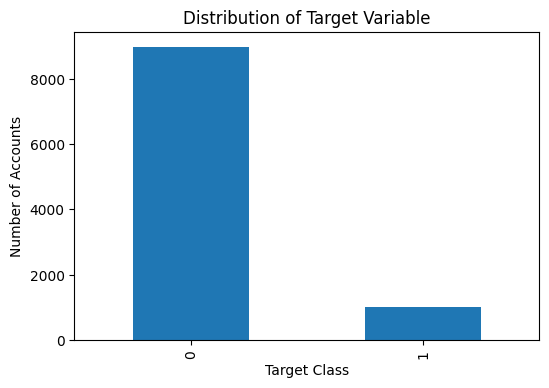

In [57]:
# count  plot
plt.figure(figsize=(6,4))
target_counts = train['TARGET'].value_counts().sort_index()
target_counts.plot(kind='bar' )
plt.title('Distribution of Target Variable')
plt.xlabel('Target Class')
plt.ylabel('Number of Accounts')

Imbalance in data observed

In [58]:
missing = train.isnull().sum()
print ( "missing values:", missing[missing > 0] )

missing values: IS_USING_CLOUD_TECHNOLOGY            589
HAS_OFFICES_IN_MULTIPLE_LOCATIONS    785
dtype: int64


**Use business logic here :**

- If no information on cloud: Assume they have it ( dont want to lose a potential customer)
- offices in multiple locations ( assume 1 location)

In [59]:
# Business logic for imputation

train['IS_USING_CLOUD_TECHNOLOGY'] = train['IS_USING_CLOUD_TECHNOLOGY'].fillna(1)
train['HAS_OFFICES_IN_MULTIPLE_LOCATIONS'] = train['HAS_OFFICES_IN_MULTIPLE_LOCATIONS'].fillna(1)
test['IS_USING_CLOUD_TECHNOLOGY'] = test['IS_USING_CLOUD_TECHNOLOGY'].fillna(1)
test['HAS_OFFICES_IN_MULTIPLE_LOCATIONS'] = test['HAS_OFFICES_IN_MULTIPLE_LOCATIONS'].fillna(1)

In [60]:
missing = train.isnull().sum()
print ( "missing values:", missing[missing > 0] )

missing values: Series([], dtype: int64)


Handling Range Features

- Examining all our range features and creating ordinal mappings that respect the natural ordering (e.g., "<10" < "10-49" < "50-199").
- Clean + map at the same time
- Continuous classes, so It will be like label encoding

In [61]:
range_features = [
    'EMPLOYEE_COUNT',
    'REVENUE_RANGE',
    'DATA_ANALYTICS_EMPLOYEES_RANGE',
    'ENGINEERING_EMPLOYEES_RANGE',
    'FINANCE_EMPLOYEES_RANGE',
    'MARKETING_EMPLOYEES_RANGE',
    'OPEN_JOB_POSTS_RANGE',
    'ESTIMATED_MONTHLY_IT_SPEND_RANGE',
    'LINKEDIN_FOLLOWERS_RANGE'
]

all_mappings = {}

for feature in range_features:
    train[feature + '_ENCODED'], mapping = smart_ordinal_encode(train[feature])
    all_mappings[feature] = mapping
    test[feature + '_ENCODED'] = test[feature].map(mapping)
    
    # Check for unmapped values
    unmapped = test[test[feature + '_ENCODED'].isna()][feature].unique()
    if len(unmapped) > 0:
        print(f" {feature} has unmapped test values: {unmapped}")
        # Fill with median
        median_val = train[feature + '_ENCODED'].median()
        test[feature + '_ENCODED'].fillna(median_val, inplace=True)

print(f"✓ Encoded {len(range_features)} range features")

# Label encoding for INDUSTRY
le = LabelEncoder()
train['INDUSTRY_ENCODED'] = le.fit_transform(train['INDUSTRY'])
test['INDUSTRY_ENCODED'] = test['INDUSTRY'].map(
    lambda x: le.transform([x])[0] if x in le.classes_ else -1
)

print("✓ Label encoded INDUSTRY")

✓ Encoded 9 range features
✓ Label encoded INDUSTRY


Outlier Check

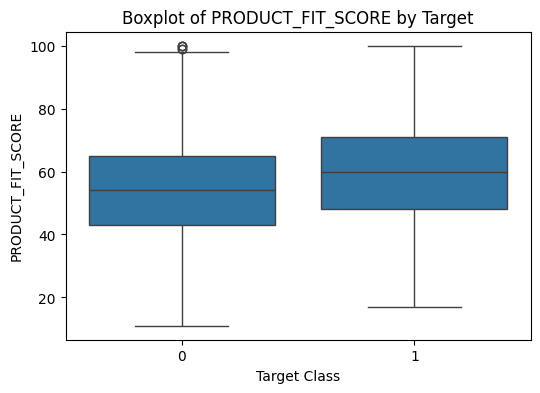

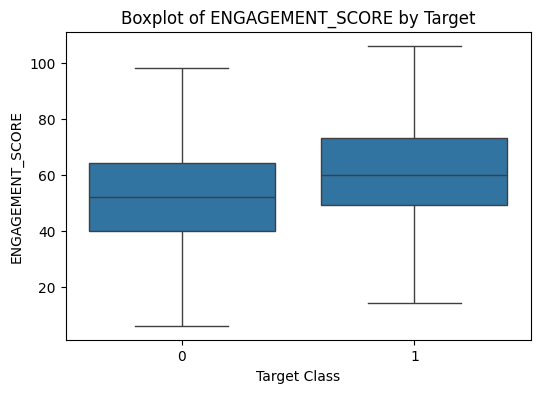

In [62]:
# boxplot of all numeric features against target
numeric_features = [ 'PRODUCT_FIT_SCORE', 'ENGAGEMENT_SCORE'  ]


for feature in numeric_features:    
    plt.figure(figsize=(6,4))
    sns.boxplot(x='TARGET', y=feature, data=train)
    plt.title(f'Boxplot of {feature} by Target')
    plt.xlabel('Target Class')
    plt.ylabel(feature)
    plt.show()

In [63]:
# one-hot encoding for categorical features
onehot_features = ['SALES_GEO', 'DEAL_COMPLEXITY', 'PUBLIC_PRIVATE_COMPANY']
train = pd.get_dummies(train, columns=onehot_features, drop_first=True) # drop_first to avoid dummy variable trap
test = pd.get_dummies(test, columns=onehot_features, drop_first=True) # drop_first to avoid dummy variable trap

# align test columns with train (excluding TARGET)
train_cols_no_target = [col for col in train.columns if col != 'TARGET']
for col in train_cols_no_target:
    if col not in test.columns:
        test[col] = 0

# ensure same column order (excluding TARGET)
test = test[[col for col in train.columns if col in test.columns]]

print(f" One-hot encoded {len(onehot_features)} categorical features")

 One-hot encoded 3 categorical features


In [64]:
# drop original unencoded columns
columns_to_drop = [
    'INDUSTRY', 'EMPLOYEE_COUNT', 'REVENUE_RANGE',
    'DATA_ANALYTICS_EMPLOYEES_RANGE', 'ENGINEERING_EMPLOYEES_RANGE',
    'FINANCE_EMPLOYEES_RANGE', 'MARKETING_EMPLOYEES_RANGE',
    'OPEN_JOB_POSTS_RANGE', 'ESTIMATED_MONTHLY_IT_SPEND_RANGE',
    'LINKEDIN_FOLLOWERS_RANGE', 'LINKED_FOLLOWER_RANGE', 'DATASET'
]

train = train.drop(columns=[col for col in columns_to_drop if col in train.columns])
test = test.drop(columns=[col for col in columns_to_drop if col in test.columns])


In [65]:
# feature engineering

#  same feature engineering to BOTH train and test
train = create_interaction_features(train)
test = create_interaction_features(test)

# Show correlations of new features
interaction_cols = ['engagement_x_size', 'fit_x_size', 'product_score_squared',
                    'engagement_squared']

print("\nInteraction feature correlations with TARGET:")
for col in interaction_cols:
    corr = train[[col, 'TARGET']].corr().iloc[0, 1]
    print(f"  {col:30s}: {corr:.4f}")


Interaction feature correlations with TARGET:
  engagement_x_size             : 0.1495
  fit_x_size                    : 0.1297
  product_score_squared         : 0.1109
  engagement_squared            : 0.1451


<Axes: >

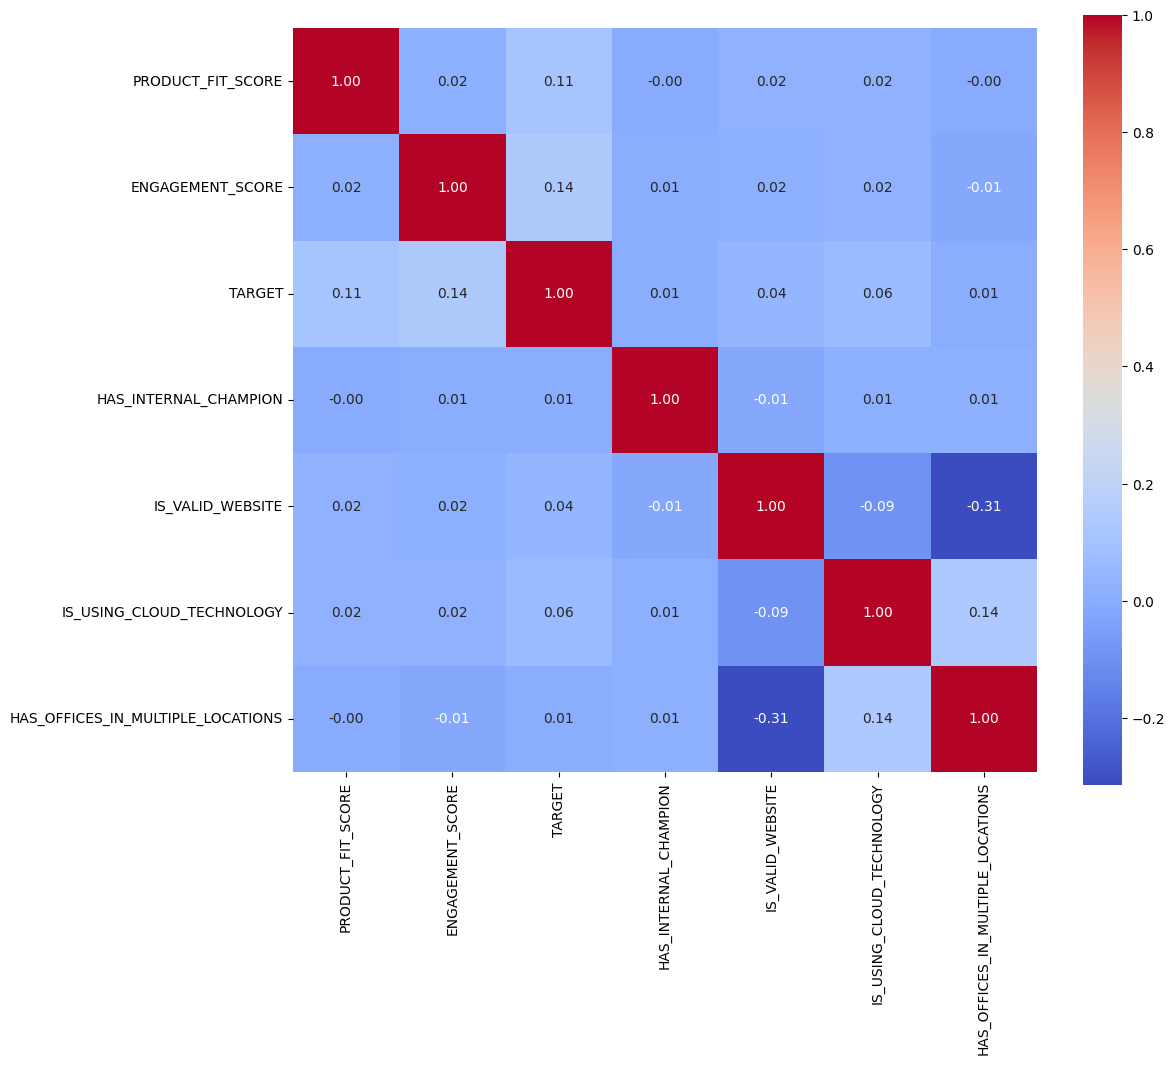

In [66]:
# heatmap of correlation matrix
plt.figure(figsize=(12,10))

numeric_cols = ['PRODUCT_FIT_SCORE', 'ENGAGEMENT_SCORE', 'TARGET']
binary_cols = ['HAS_INTERNAL_CHAMPION', 'IS_VALID_WEBSITE', 
               'IS_USING_CLOUD_TECHNOLOGY', 'HAS_OFFICES_IN_MULTIPLE_LOCATIONS']

corr_matrix = train[numeric_cols + binary_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)


Insights

- Engagement Score and Product fit score are strong predictors
- No high correlations found - features are independent, important and contribute to the target prediction
- The binary features are weak predictors individually.

Creating a stratified train-validation split (70-30) to preserve the class imbalance ratio in both sets
self note: Stratification ensures both train and validation sets have the same distribution

**Summary of EDA:**

- Excel Date Corruption Handling
- Duplicate Columns and Irrelevant Columns Handling
- Missing Values handle w business logic
- Range conversion to Ordinal encoding
- Encoding
- Outlier Check
- Correlation matrix to find correlated features

**Feature Engineering**
- Drop features with correlation < 0.05 (very weak predictors)
- Create interaction features (ENGAGEMENT_SCORE × EMPLOYEE_COUNT_ENCODED, etc.)

**Strategy to handle imbalance**
- stratification
- class weights
- SMOTE


SMOTE = Synthetic Minority Over-sampling Technique

In [104]:
# Prepare features
feature_cols = [col for col in train.columns if col not in ['ACCOUNT_ID', 'TARGET']]
from imblearn.over_sampling import SMOTE

# Prepare features
X = train[feature_cols]
y = train['TARGET']

#   SMOTE before train/val split
print(f"Original class distribution: {y.value_counts().to_dict()}")

smote = SMOTE(sampling_strategy=0.5, random_state=42)  #  2:1 instead of 9:1
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"After SMOTE: {pd.Series(y_resampled).value_counts().to_dict()}")

# Now split
X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    stratify=y_resampled,
    random_state=42
)


print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

# Calculate class weight for XGBoost
n_class_0 = (y_train == 0).sum()
n_class_1 = (y_train == 1).sum()
# scale_pos_weight = (n_class_0 / n_class_1) * 2

# print(f"\nClass imbalance ratio: {scale_pos_weight:.2f}")

Original class distribution: {0: 9000, 1: 1000}
After SMOTE: {0: 9000, 1: 4500}
Training set: 10800 samples
Validation set: 2700 samples


Sanity Check to view cleaned data

In [105]:
train.to_excel( r"C:\Users\Advait Shinde\AgenticAIFrameworks\sf_ml_th\train_processed.xlsx", index=False )
test.to_excel( r"C:\Users\Advait Shinde\AgenticAIFrameworks\sf_ml_th\test_processed.xlsx", index=False )

# Baseline Model Training

In [106]:
# BASELINE MODEL: Logistic Regression

lr_model = LogisticRegression(
    # class_weight='balanced', # Ensure balanced classes          # used smote instead
    random_state=42,
    max_iter=1000,
    solver='liblinear'
)

lr_model.fit(X_train, y_train)

# Evaluate on validation set
y_val_probs = lr_model.predict_proba(X_val)[:, 1]
val_roc_auc = roc_auc_score(y_val, y_val_probs)
val_pr_auc = average_precision_score(y_val, y_val_probs)

print(f"\nLogistic Regression Validation ROC-AUC: {val_roc_auc:.4f}")
print(f"Logistic Regression Validation PR-AUC: {val_pr_auc:.4f}")

# classification report
y_val_preds = (y_val_probs >= 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_val, y_val_preds))





Logistic Regression Validation ROC-AUC: 0.8601
Logistic Regression Validation PR-AUC: 0.8009

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1800
           1       0.80      0.64      0.71       900

    accuracy                           0.83      2700
   macro avg       0.82      0.78      0.79      2700
weighted avg       0.82      0.83      0.82      2700



Insights: 

- ROC-AUC : Slightly over randomly guessing


- The Precision Problem: 16% for Engaged Class ( BEFORE SMOTE)
- After SMOTE **80**



Causes: 

- Non-Linear Relationships
- Imbalance causes undertraining of label with 18% accuracy.

**Why I'm choosing a Tree based model**

- capturing non linearity
- handling categorical labels better
- more generalization  (robust to noise)
- can handle class imbalance with weighted labels

# Final Model : Random Forest 

In [108]:
# final model 

from sklearn.ensemble import RandomForestClassifier

# Train XGBoost model
rf_model = RandomForestClassifier(

    n_estimators=200,
    max_depth=10,
    # class_weight='balanced',
    random_state=42,

)


rf_model.fit(X_train, y_train)

# Validation metrics
y_val_proba = rf_model.predict_proba(X_val)[:, 1]
y_val_pred = rf_model.predict(X_val)
roc_auc = roc_auc_score(y_val, y_val_proba)
pr_auc = average_precision_score(y_val, y_val_proba)


print(f"  Validation ROC-AUC: {roc_auc:.4f}")
print(f"  Validation PR-AUC: {pr_auc:.4f}")



  Validation ROC-AUC: 0.9463
  Validation PR-AUC: 0.9322


In [109]:
print (classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.89      0.98      0.94      1800
           1       0.96      0.77      0.85       900

    accuracy                           0.91      2700
   macro avg       0.93      0.88      0.89      2700
weighted avg       0.92      0.91      0.91      2700



In [110]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))


 10 Most Important Features:
                          feature  importance
        IS_USING_CLOUD_TECHNOLOGY    0.190208
HAS_OFFICES_IN_MULTIPLE_LOCATIONS    0.106939
                engagement_x_size    0.066520
               engagement_squared    0.065373
                 ENGAGEMENT_SCORE    0.054840
                       fit_x_size    0.052781
               SALES_GEO_Americas    0.052068
                   SALES_GEO_EMEA    0.046765
            product_score_squared    0.039333
                PRODUCT_FIT_SCORE    0.034238


In [112]:
#  same feature columns as training
test_features = test[feature_cols]

print(f"Test features shape: {test_features.shape}")
print(f"Training features shape: {X.shape}")



# Generate predictions using calibrated model
test_probabilities = rf_model.predict_proba(test_features)[:, 1]


print(f"\nProbability Distribution:")
print(f"  Min:    {test_probabilities.min():.4f}")
print(f"  25th:   {np.percentile(test_probabilities, 25):.4f}")
print(f"  Median: {np.percentile(test_probabilities, 50):.4f}")
print(f"  75th:   {np.percentile(test_probabilities, 75):.4f}")
print(f"  Max:    {test_probabilities.max():.4f}")
print(f"  Mean:   {test_probabilities.mean():.4f}")

Test features shape: (10000, 26)
Training features shape: (10000, 26)

Probability Distribution:
  Min:    0.0052
  25th:   0.0984
  Median: 0.1575
  75th:   0.2472
  Max:    0.7450
  Mean:   0.1859


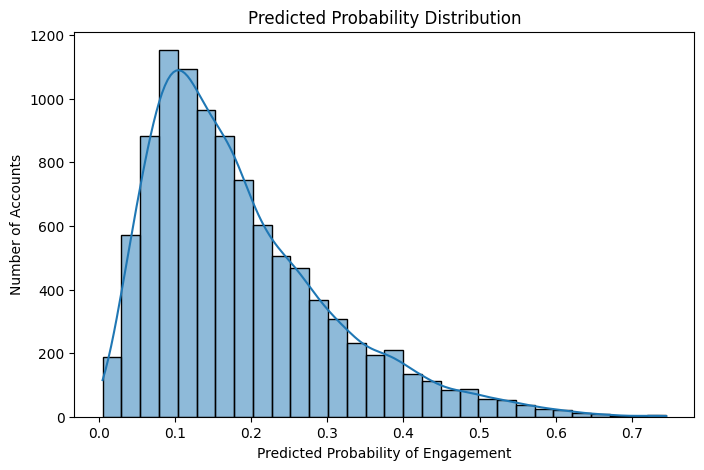

In [113]:
# plot probability distribution
plt.figure(figsize=(8,5))
sns.histplot(test_probabilities, bins=30, kde=True)
plt.title('Predicted Probability Distribution')
plt.xlabel('Predicted Probability of Engagement')
plt.ylabel('Number of Accounts')
plt.show()

This distribution represents the pessimistic nature of the model that is caused by the initial imabalance

In [ ]:
def probability_to_aps(probability):
    """
    Convert predicted probability to Account Propensity Score (APS)
    
    Business Logic:
    - Scale: 0-100 (easier to understand than 0-1 probability)
    - Non-linear transformation to spread out middle values
    - Emphasizes differences in high-probability accounts
    
    Buckets:
    - 0-30:   Minimal Priority
    - 31-60:  Low Priority
    - 51-80:  Medium Priority
    - 71-100:  High Priority (Hot Leads)
    """
    # Non-linear transformation: emphasize high probabilities
    #  square root to compress lower probabilities, expand higher ones
    aps_raw = np.sqrt(probability) * 100
    
    # Ensure bounds
    aps = np.clip(aps_raw, 0, 100)
    
    return aps

# generous function to assign buckets: since you dont want to miss potential leads
def aps_to_bucket(aps_score):

    """Assign priority bucket based on APS score"""

    if aps_score >= 71:
        return "High Priority (Hot Lead)"
    elif aps_score >= 51:
        return "Medium Priority"
    elif aps_score >= 31:
        return "Low Priority"
    
    else:
        return "Minimal Priority"


#  APS scores
aps_scores = probability_to_aps(test_probabilities)

# Create output dataframe
results_df = pd.DataFrame({
    'account_id': test['ACCOUNT_ID'],
    'predicted_probability': test_probabilities,
    'APS_score': np.round(aps_scores, 2),
    # 'PRIORITY_BUCKET': [aps_to_bucket(score) for score in aps_scores]
})

# Sort by APS score (highest first)
results_df = results_df.sort_values('APS_score', ascending=False).reset_index(drop=True)



print("\nAPS Score Distribution:")
print(results_df['APS_score'].describe())

print("\nPriority Bucket Distribution:")
# print(results_df['PRIORITY_BUCKET'].value_counts().sort_index())


APS Score Distribution:
count    10000.000000
mean        41.013274
std         13.304890
min          7.240000
25%         31.370000
50%         39.690000
75%         49.720000
max         86.310000
Name: APS_score, dtype: float64

Priority Bucket Distribution:


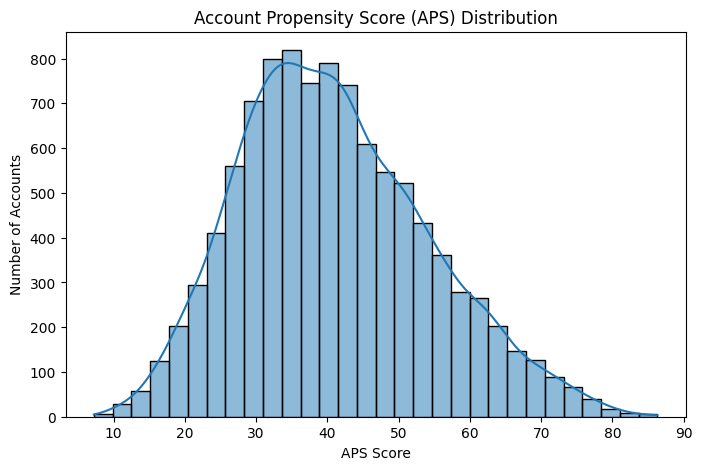

In [116]:
# visualize APS score distribution with buckets
plt.figure(figsize=(8,5))
sns.histplot(results_df['APS_score'], bins=30, kde=True)
plt.title('Account Propensity Score (APS) Distribution')
plt.xlabel('APS Score')
plt.ylabel('Number of Accounts')
plt.show()



In [115]:
results_df.to_csv(OUTPUT_PATH, index=False)


Takeaways: 

- Logistic Regression: 0.8 ROC-AUC

- Random Forest: 0.94 ROC-AUC

- Engagement Score being the best feature via correlation still weakly predicts engagement
- Other features having low correlation
- Some features dont correlate
- Class imbalance
